# Do Rolexes beat the S&P? ⌚
### The "luxury watches are an asset class" bubble, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Watches_beat_the_S%26P%3F: Busted](https://img.shields.io/badge/Watches_beat_the_S%26P%3F-Busted-8b949e?style=flat-square)

You've heard it at every dinner party since 2021: *"forget stocks — a steel Rolex Daytona, a Patek Nautilus, an AP Royal Oak only goes **up**. Watches are an asset class now. They beat the S&P."* For about eighteen glorious months it even looked true: prices doubled, people flipped watches they couldn't get for triple retail.

Then the music stopped. This notebook lines the watch market up next to the S&P 500 — on return, on risk, and on what it actually **costs to buy and sell a watch** — and asks the only question that matters: *would you have been richer in an index fund?*

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the cost algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** Real watch-resale indices (WatchCharts, Subdial) aren't free to pull, so the resale line below is a **small, clearly-cited, approximate** reconstruction of public reporting — a **proxy**, never presented as the live index. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from watch_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_resale_index()                       # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| resale-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2018 → 2025', 'idx_levels': {2018: 100, 2019: 112, 2020: 130, 2021: 196, 2022: 168, 2023: 150, 2024: 141, 2025: 148}, 'idx_yoy': {2019: 12.0, 2020: 16.1, 2021: 50.8, 2022: -14.3, 2023: -10.7, 2024: -6.0, 2025: 5.0}, 'peak_date': '2022-03', 'peak_level': 220, 'peak_avg_price': 45108, 'peak_trough': -35.9, 'idx_cagr': 5.76, 'idx_vol': 22.2, 'idx_sharpe': 0.34, 'idx_mdd': -28.1, 'spy_cagr_ye': 15.03, 'spy_vol_ye': 17.5, 'spy_mdd_ye': -18.3, 'excess_mean': -9.52, 'excess_t': -1.054, 'excess_p': 0.34, 'excess_n': 6, 'wosg_cagr': 6.76, 'wosg_vol': 55.2, 'wosg_sharpe': 0.41, 'wosg_mdd': -77.0, 'wosg_alpha': -11.22, 'wosg_beta': 2.05, 'wosg_t': -0.7, 'wosg_p': 0.488, 'wosg_n': 79, 'cfr_cagr': 17.07, 'cfr_vol': 32.8, 'cfr_sharpe': 0.64, 'cfr_mdd': -36.3, 'cfr_alpha': 3.9, 'cfr_beta': 1.04, 'cfr_t': 0.41, 'cfr_p': 0.684, 'cfr_n': 83, 'spy_cagr': 16.06, 'spy_vol': 16.7, 'spy_sharpe': 0.98, 'spy_mdd': -24.0, 'carry_gross': 5.76, 'carry_spread': -7.17, 'carry_insure': -1.0, 'carry_net': -2.8, 'syn_peak': 1015, 'syn_end': 313, 'syn_cagr': 15.88, 'syn_sharpe': 0.81, 'syn_mdd': -69.2}


equity-proxy cache present: True | resale-index years: 2018 -> 2025


## The answer first

| Question | Answer |
|---|---|
| Did watch prices really moon? | **Yes — for a while.** The resale index ran from 100 (2018) to ~196 by end-2021 and blew off near **2022-03** (avg secondhand price ≈ \$45,108). The mania was real. |
| Did it last? | **No.** From the March-2022 top it **round-tripped -36%** into 2024. A bubble, not a re-rating. |
| Did watches beat the S&P? | **No — they lost.** Over 2018–2025 the index compounded at **~6%/yr** vs **~15%/yr** for SPY — with *more* swings and a *deeper* drawdown. |
| Could you at least buy the trade? | **Not profitably.** The listed watch stocks are alpha-free, high-beta beta (one fell **-77%**), and once you pay the dealer spread to flip the metal, the watches' return goes **negative (-2.8%/yr)**. |

> The mania was real. The *asset class* was not. The S&P won every column that matters.

## 1 · The claim

> *"Luxury watches — Rolex, Patek Philippe, Audemars Piguet — are a store of value that beats the stock market. Buy the right reference, wait, sell it for more. The rich have always known watches are money you can wear."*

It's a *steelman-able* claim: between 2020 and early 2022 the secondary market genuinely melted up. Stimulus cheques, zero rates, lockdown boredom and a wall of social-media flipping pushed hyped steel sports models to 2–5× their retail list. A Patek Nautilus 5711 changed hands near \$103,000; the average secondhand watch peaked around \$45,108. For a moment, "watches beat stocks" was simply a fact.

## 2 · So what?

If it were durably true, it would be a big deal: an asset that beats equities *and* you get to wear it, uncorrelated with your stock portfolio, inflation-proof. That's the pitch every watch dealer and lifestyle-finance influencer leans on. But "it went up for two years" and "it's an asset class that beats the S&P" are very different statements. The first is about a **bubble**; the second is a claim about the **long-run, risk-adjusted, net-of-cost** return. We can check the second directly.

## 3 · How would we even know?

Three honest comparisons, each against the S&P 500 (SPY):

1. **The resale index vs SPY.** Put the (cited, approximate) secondary-market watch index next to SPY on the same 2018–2025 clock — return, volatility, worst drawdown.
2. **The thing you can actually buy.** You can't buy "the watch index." You *can* buy the listed retailer **Watches of Switzerland** and the group **Richemont**. Do they deliver the watch trade's return — or just stock-market risk?
3. **The cost of flipping.** A watch isn't an ETF: you buy near retail-plus and sell at a wholesale discount, and it sits insured in a safe for years. Charge that, and see what's left.

**What would make us say "asset class"?** The index beats the S&P on *risk-adjusted, net-of-cost* return. Anything less is a bubble story.

## 4 · The teardown — let's actually look

**First: the round-trip.** Here is the (approximate, cited) resale index — the melt-up and the giveback.

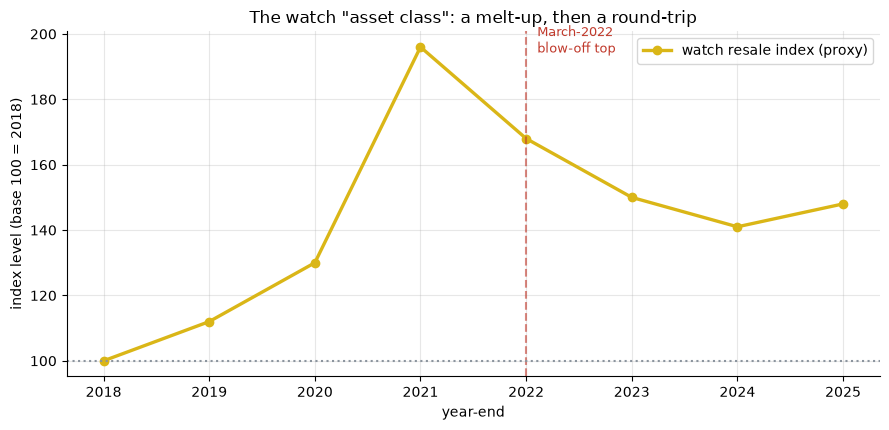

levels: {2018: 100, 2019: 112, 2020: 130, 2021: 196, 2022: 168, 2023: 150, 2024: 141, 2025: 148}
down -36% from the March-2022 peak to the 2024 low


In [2]:
yrs = list(R['idx_levels'].keys())
lv = [IDX.loc[f'{y}-12-31'] for y in yrs] if True else list(R['idx_levels'].values())
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.4, label='watch resale index (proxy)')
ax.axvline(2022, ls='--', c=RED, alpha=.6)
ax.annotate('March-2022\nblow-off top', (2022, max(lv)), textcoords='offset points',
            xytext=(8, -4), color=RED, fontsize=9)
ax.axhline(100, ls=':', c=GREY)
ax.set_xlabel('year-end'); ax.set_ylabel('index level (base 100 = 2018)')
ax.set_title('The watch "asset class": a melt-up, then a round-trip'); ax.legend()
plt.tight_layout(); plt.show()
print('levels:', {y:int(round(float(v))) for y,v in zip(yrs, lv)})
print(f"down {R['peak_trough']:.0f}% from the March-2022 peak to the 2024 low")

It nearly **doubled** into 2021, then gave most of it back: **-36%** from the top. If you bought at the peak — exactly when the "asset class" headlines were loudest — you spent two years underwater. That's not how a store of value behaves; it's how a bubble behaves.

**Now the race: watches vs the S&P.** Same money, same years — who's richer at the end?

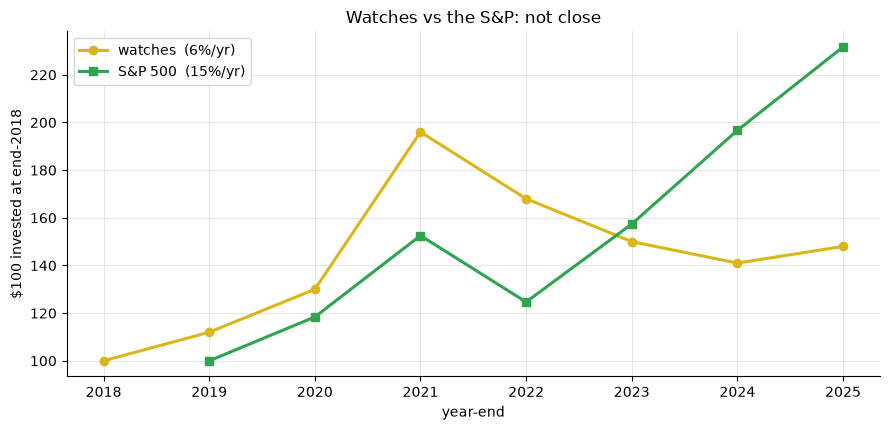

watches CAGR ~5.8%  vs  SPY CAGR ~15.0%  |  watches maxDD -28%  vs  SPY -18%


In [3]:
if HAVE_PROXIES:
    spy = PROX['SPY']; spy_ye = spy.resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    spy_norm = spy_ye/spy_ye.iloc[0]*100
    sx = [d.year for d in spy_norm.index]; sy = list(spy_norm.values)
else:
    sx, sy = yrs, [100*(1+R['spy_cagr_ye']/100)**(y-2018) for y in yrs]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(yrs, [float(v) for v in lv], 'o-', c=AMBER, lw=2.2, label=f"watches  ({R['idx_cagr']:.0f}%/yr)")
ax.plot(sx, sy, 's-', c=GREEN, lw=2.2, label=f"S&P 500  ({R['spy_cagr_ye']:.0f}%/yr)")
ax.set_xlabel('year-end'); ax.set_ylabel('$100 invested at end-2018')
ax.set_title('Watches vs the S&P: not close'); ax.legend()
plt.tight_layout(); plt.show()
print(f"watches CAGR ~{R['idx_cagr']:.1f}%  vs  SPY CAGR ~{R['spy_cagr_ye']:.1f}%  |  "
      f"watches maxDD {R['idx_mdd']:.0f}%  vs  SPY {R['spy_mdd_ye']:.0f}%")

The S&P didn't just win — it **lapped** the watches: **~15%/yr** vs **~6%/yr**, with a *shallower* worst drop. More return, less pain. Even the gaudy 2020–21 spike isn't enough to save the watch line over the full cycle.

**"Fine — I'll buy the watch *stocks*."** You can: Watches of Switzerland (the big Rolex/Patek dealer) and Richemont (Cartier/IWC). Do they hand you the watch trade — or just a wilder ride to roughly the same place?

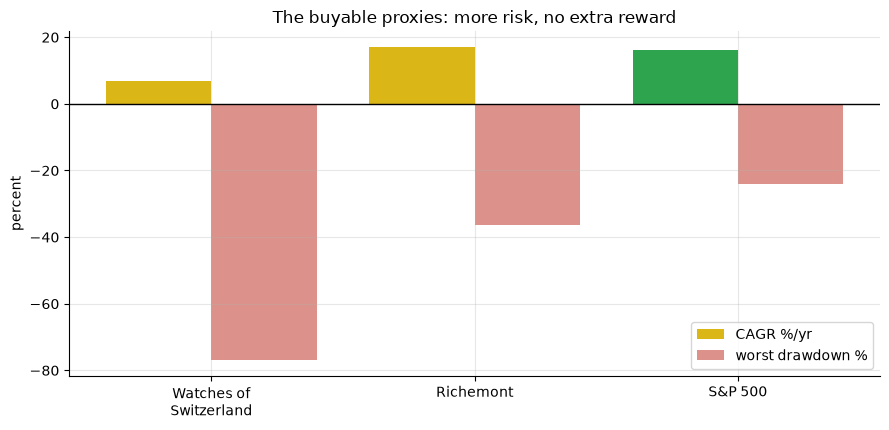

WOSG.L: CAGR 6.8% but maxDD -77% (beta 2.0)
CFR.SW: CAGR 17.1%, basically SPY at twice the vol


In [4]:
names = ['Watches of\nSwitzerland', 'Richemont', 'S&P 500']
cagrs = [R['wosg_cagr'], R['cfr_cagr'], R['spy_cagr']]
mdds  = [R['wosg_mdd'], R['cfr_mdd'], R['spy_mdd']]
x = np.arange(3); fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x-.2, cagrs, .4, color=[AMBER,AMBER,GREEN], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.55, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The buyable proxies: more risk, no extra reward'); ax.legend()
plt.tight_layout(); plt.show()
print(f"WOSG.L: CAGR {R['wosg_cagr']:.1f}% but maxDD {R['wosg_mdd']:.0f}% (beta {R['wosg_beta']:.1f})")
print(f"CFR.SW: CAGR {R['cfr_cagr']:.1f}%, basically SPY at twice the vol")

Watches of Switzerland did the bubble *with leverage*: it crashed **-77%** as the mania deflated — the opposite of a safe-haven. Richemont roughly matched the S&P's return but at far higher volatility. Neither pays you for the extra white-knuckle risk.

**The part the pitch never mentions: it costs real money to flip a watch.** You buy near retail-plus, sell at a dealer's wholesale discount (~20% round-trip), and insure/store it for years. Charge that against the watch index's gross return:

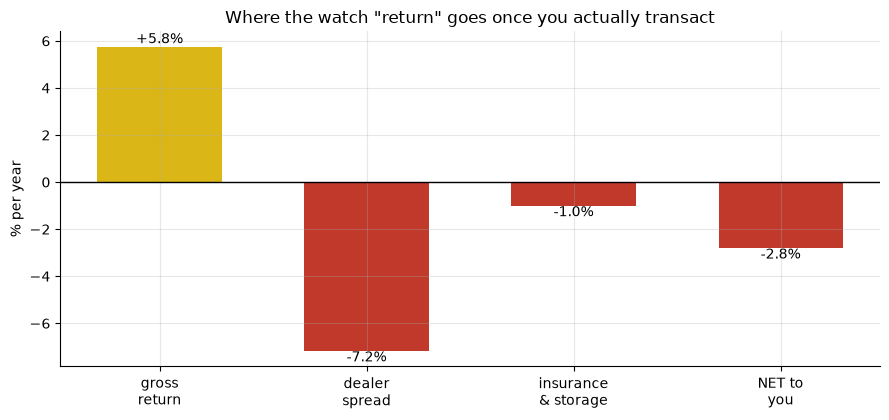

gross +5.8%/yr  ->  NET -2.8%/yr after spread + carry


In [5]:
labels = ['gross\nreturn', 'dealer\nspread', 'insurance\n& storage', 'NET to\nyou']
vals = [R['carry_gross'], R['carry_spread'], R['carry_insure'], R['carry_net']]
cols = [AMBER, RED, RED, (RED if R['carry_net']<0 else GREEN)]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('% per year')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('Where the watch "return" goes once you actually transact')
plt.tight_layout(); plt.show()
print(f"gross {R['carry_gross']:+.1f}%/yr  ->  NET {R['carry_net']:+.1f}%/yr after spread + carry")

There it is. A gross **5.8%/yr** that already lost to the S&P turns **negative (-2.8%/yr)** the moment you pay to buy, sell and hold the physical watch. A boring T-bill beat it; the index fund laps it.

## 5 · The verdict

- **Signal — None.** Watches returned ~6%/yr vs ~15%/yr for the S&P — they *under*-performed, with more risk. No evidence they beat stocks.
- **Tradability — Mirage.** Illiquid, high-carry; the gross return goes **negative** after the dealer spread, and the buyable proxies are alpha-free high-beta beta.
- **Watches beat the S&P? — Busted.** Every column — return, risk-adjusted return, drawdown, net-of-cost — goes to the index fund.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people at the end of 2018, each with \$10,000. One buys an S&P index fund. The other becomes a watch flipper — buys, insures, stores, and eventually sells, paying the real frictions. Where do they land by end-2025?

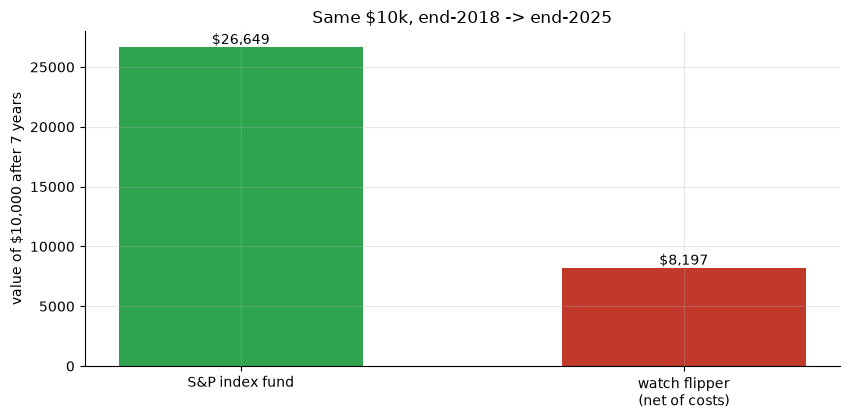

S&P index fund: $26,649   |   watch flipper (net): $8,197


In [6]:
start = 10_000.0
spy_end = start*(1+R['spy_cagr_ye']/100)**7
watch_end = start*(1+R['carry_net']/100)**7   # net of spread + carry
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['S&P index fund', 'watch flipper\n(net of costs)'], [spy_end, watch_end],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([spy_end, watch_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years')
ax.set_title('Same $10k, end-2018 -> end-2025'); plt.tight_layout(); plt.show()
print(f'S&P index fund: ${spy_end:,.0f}   |   watch flipper (net): ${watch_end:,.0f}')

The index-fund investor roughly **triples** their money doing nothing. The flipper — after spreads, insurance and a bubble that round-tripped — ends up with **less than they started with**. The people who really made money in watches bought *before* March 2022 and sold near the top: bubble survivors, not asset-class investors. You only hear from them.

## 7 · Going further 🚪

- **Pull the real index yourself.** Our resale line is a cited *approximation*; WatchCharts / Subdial publish the live series. Swap it in — the shape (and the verdict) won't move, but you'll have the exact tape.
- **The collectibles pattern.** Wine, art, sneakers, trading cards: every "passion asset" tells the same story — real spikes, brutal carry, equities win net of cost (see [docs/references.md](../docs/references.md)).
- **The survivorship angle.** [Study 301 — Triple-RSI](../../301-triple-rsi/) is the same shape in stocks: a handful of winners narrated as a system.

*Think a specific reference (a steel Daytona, a 5711) beat the S&P net of every cost? Pull its WatchCharts history, charge the spread, and show it — then check it wasn't just one lucky buy near the bottom.*